In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("austin_weather.csv")
df.head()


,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,...,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
0,2013-12-21,74,60,45,67,49,43,93,75,57,...,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
1,2013-12-22,56,48,39,43,36,28,93,68,43,...,30.13,29.87,10,10,5,16,6,25,0,
2,2013-12-23,58,45,32,31,27,23,76,52,27,...,30.49,30.41,10,10,10,8,3,12,0,
3,2013-12-24,61,46,31,36,28,21,89,56,22,...,30.45,30.3,10,10,7,12,4,20,0,
4,2013-12-25,58,50,41,44,40,36,86,71,56,...,30.33,30.27,10,10,7,10,2,16,T,


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Date                        1319 non-null   object
 1   TempHighF                   1319 non-null   int64 
 2   TempAvgF                    1319 non-null   int64 
 3   TempLowF                    1319 non-null   int64 
 4   DewPointHighF               1319 non-null   object
 5   DewPointAvgF                1319 non-null   object
 6   DewPointLowF                1319 non-null   object
 7   HumidityHighPercent         1319 non-null   object
 8   HumidityAvgPercent          1319 non-null   object
 9   HumidityLowPercent          1319 non-null   object
 10  SeaLevelPressureHighInches  1319 non-null   object
 11  SeaLevelPressureAvgInches   1319 non-null   object
 12  SeaLevelPressureLowInches   1319 non-null   object
 13  VisibilityHighMiles         1319 non-null   obje

In [4]:
df.describe()


,TempHighF,TempAvgF,TempLowF
count,1319.000000,1319.000000,1319.000000
mean,80.862775,70.642911,59.902957
std,14.766523,14.045904,14.190648
min,32.000000,29.000000,19.000000
25%,72.000000,62.000000,49.000000
50%,83.000000,73.000000,63.000000
75%,92.000000,83.000000,73.000000
max,107.000000,93.000000,81.000000


In [8]:

# Replacing "T" (trace rainfall) and "-" (missing values)

df.replace("T", 0.01, inplace=True)
df.replace("-", np.nan, inplace=True)


In [10]:
df = df.apply(lambda x: pd.to_numeric(x, errors='coerce'))
df.dropna(inplace=True)


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        0 non-null      float64
 1   TempHighF                   0 non-null      int64  
 2   TempAvgF                    0 non-null      int64  
 3   TempLowF                    0 non-null      int64  
 4   DewPointHighF               0 non-null      float64
 5   DewPointAvgF                0 non-null      float64
 6   DewPointLowF                0 non-null      float64
 7   HumidityHighPercent         0 non-null      float64
 8   HumidityAvgPercent          0 non-null      float64
 9   HumidityLowPercent          0 non-null      float64
 10  SeaLevelPressureHighInches  0 non-null      float64
 11  SeaLevelPressureAvgInches   0 non-null      float64
 12  SeaLevelPressureLowInches   0 non-null      float64
 13  VisibilityHighMiles         0 non-null      float64


In [12]:
features = ["TempAvgF", 
            "HumidityAvgPercent",
            "DewPointAvgF", 
            "VisibilityAvgMiles",
            "WindAvgMPH"]

X = df[features]
y = df["PrecipitationSumInches"]


In [14]:
df = pd.read_csv("austin_weather.csv")


In [15]:
df.replace("T", 0.01, inplace=True)
df.replace("-", np.nan, inplace=True)


In [16]:
columns_to_convert = [
    "TempAvgF",
    "HumidityAvgPercent",
    "DewPointAvgF",
    "VisibilityAvgMiles",
    "WindAvgMPH",
    "PrecipitationSumInches"
]

for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=columns_to_convert, inplace=True)


In [17]:
print(df.shape)


(1307, 21)


In [18]:
X = df[columns_to_convert[:-1]]
y = df["PrecipitationSumInches"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [19]:
print(df.shape)


(1307, 21)


In [20]:
features = ["TempAvgF",
            "HumidityAvgPercent",
            "DewPointAvgF",
            "VisibilityAvgMiles",
            "WindAvgMPH"]

X = df[features]
y = df["PrecipitationSumInches"]


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [23]:
y_pred = model.predict(X_test)


In [24]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


R2 Score: 0.14162088576792897
Mean Squared Error: 0.05818232914666212


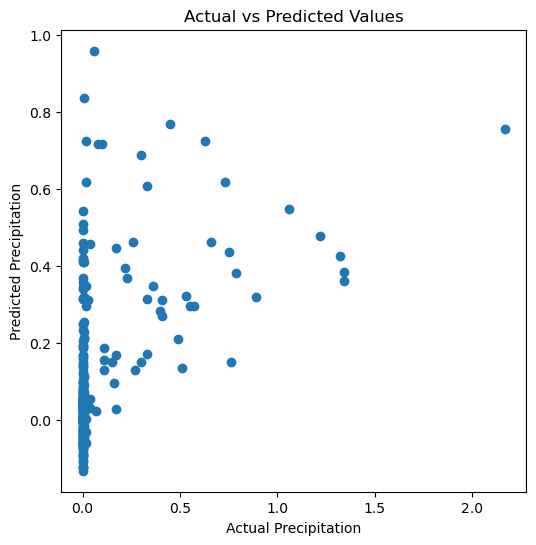

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Precipitation")
plt.ylabel("Predicted Precipitation")
plt.title("Actual vs Predicted Values")
plt.show()
